In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Загрузка данных из отдельных файлов
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
with open('map.json', 'r') as f:
    map_data = json.load(f)

print(f"Train: {train.shape}")
print(f"Test: {test.shape}")
display(train.head())
display(test.head())

Train: (502, 25)
Test: (1998, 25)


,longitude,latitude,target,habitat_quality_score,biodiversity_index,canopy_density,soil_moisture_level,forest_age_years,tree_density_per_hectare,annual_rainfall_mm,habitat_fragmentation_index,predator_pressure_score,vegetation_complexity,forest_type,climate_zone,soil_type,disturbance_level,conservation_status,dominant_tree_species,water_source_type,temperature_variability,elevation_range,human_activity_index,canopy_height_avg,seasonal_variation_score
0,-68.624132,-32.868160,0,38.746018,0.869221,0.584679,6.031727,97.911830,396.493164,1293.066100,0.507221,1.040142,3.0,tropical_rainforest,montane,peat,low,unprotected,palm,stream,4.037666,730.654928,0.075256,6.710190,6.874974
1,-51.964445,1.978971,0,17.456343,3.414865,0.327984,4.694215,169.739698,350.579890,2353.814818,0.247614,7.522185,9.0,dry_forest,temperate,loam,minimal,unprotected,pine,none,5.882945,316.780429,3.614124,30.770752,6.384739
2,-50.585866,-5.300425,0,43.883046,1.930266,0.750885,7.864357,214.602112,237.872776,1147.090078,0.574802,3.255146,4.0,dry_forest,subtropical,loam,moderate,unprotected,palm,seasonal,3.366330,474.802210,2.251489,5.000000,5.690438
3,-64.666741,-32.100087,0,29.736058,1.724559,0.322355,4.448480,275.153342,458.725205,1252.207036,0.648601,6.404152,9.0,tropical_rainforest,temperate,loam,low,buffer_zone,mahogany,stream,8.984897,187.292371,3.063365,16.284970,6.328448
4,-72.512342,-5.718456,1,66.547123,9.257867,0.428812,3.822563,179.540444,346.391230,604.782917,0.732562,4.880406,2.0,dry_forest,tropical,clay,low,unprotected,bamboo,seasonal,3.966467,191.639490,3.888626,36.796504,5.780874


,longitude,latitude,habitat_quality_score,biodiversity_index,canopy_density,soil_moisture_level,forest_age_years,tree_density_per_hectare,annual_rainfall_mm,habitat_fragmentation_index,predator_pressure_score,vegetation_complexity,forest_type,climate_zone,soil_type,disturbance_level,conservation_status,dominant_tree_species,water_source_type,temperature_variability,elevation_range,human_activity_index,canopy_height_avg,seasonal_variation_score,ID
0,-72.102869,19.626859,45.511580,3.743753,0.648016,3.260149,172.921350,226.157888,1177.791799,0.558007,7.795448,3.0,secondary_forest,montane,laterite,high,unprotected,kapok,stream,5.205539,318.967595,3.626041,23.686628,6.492307,0
1,-50.441167,-8.396785,34.751298,4.712511,0.226638,5.191137,357.568190,429.731562,1922.536202,0.332591,5.712367,7.0,dry_forest,temperate,sandy,moderate,protected,palm,seasonal,8.634001,184.900374,1.830241,28.697284,4.313709,1
2,-58.372430,0.312577,73.162533,2.579567,0.747227,7.533181,300.220431,144.840477,1844.822680,0.654825,2.073700,1.0,cloud_forest,subtropical,loam,high,protected,pine,none,5.382953,536.571256,0.074063,26.366329,3.480140,2
3,-76.362920,-14.279388,86.832262,4.097908,0.602197,6.429846,325.612904,323.532762,1571.667498,0.383862,0.798348,5.0,dry_forest,tropical,alluvial,minimal,buffer_zone,pine,stream,8.282785,649.036995,0.000000,34.803212,3.417066,3
4,-67.162159,6.450007,63.631579,4.895632,1.000000,4.502920,308.714905,693.209698,1688.758358,0.344897,1.378641,1.0,tropical_rainforest,subtropical,sandy,minimal,protected,pine,stream,10.690082,388.522453,4.500977,45.697464,6.823274,4


## Функция для визуализации

Создадим вспомогательную функцию для визуализации точек на карте с контуром береговой линии.

In [7]:
def plot_map(points, coastline, color_by=None, figsize=(5, 5)):
    """
    Визуализирует точки на карте с контуром береговой линии.
    
    Параметры:
    ----------
    points : pd.DataFrame
        DataFrame с точками, должен содержать колонки 'longitude' и 'latitude'
    coastline : list
        Список координат береговой линии [[lon1, lat1], [lon2, lat2], ...]
    color_by : str, optional
        Название колонки для раскраски точек. Если None, все точки одного цвета
    figsize : tuple, optional
        Размер фигуры (ширина, высота)
    
    Пример использования:
    --------------------
    # Простая визуализация без раскраски
    plot_map(train, coastline)
    
    # С раскраской по таргету
    plot_map(train, coastline, color_by='target')
    
    # Изменение размера
    plot_map(train, coastline, color_by='target', figsize=(16, 10))
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Рисуем береговую линию
    if coastline:
        coastline_array = np.array(coastline)
        
        # Рисуем все точки побережья как плотный scatter с квадратными маркерами
        ax.scatter(coastline_array[:, 0], coastline_array[:, 1], 
                  s=1.5, marker='s', color='#CCCCCC', alpha=0.7, label='Coastline')
    
    # Рисуем точки
    if color_by is None:
        # Без раскраски - все точки одного цвета
        ax.scatter(points['longitude'], points['latitude'], 
                   s=50, alpha=0.6, edgecolors='black', linewidths=0.5,
                   label='Points')
    else:
        # С раскраской по указанной колонке
        if points[color_by].dtype in ['object', 'category']:
            # Категориальная переменная
            unique_vals = points[color_by].unique()
            colors = plt.cm.tab10(np.linspace(0, 1, len(unique_vals)))
            
            for i, val in enumerate(unique_vals):
                mask = points[color_by] == val
                ax.scatter(points[mask]['longitude'], points[mask]['latitude'],
                          s=50, alpha=0.6, edgecolors='black', linewidths=0.5,
                          label=f'{color_by}={val}', color=colors[i])
        else:
            # Числовая переменная
            scatter = ax.scatter(points['longitude'], points['latitude'],
                               c=points[color_by], cmap='RdYlGn',
                               s=50, alpha=0.6, edgecolors='black', linewidths=0.5)
            plt.colorbar(scatter, ax=ax, label=color_by)
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Карта точек (n={len(points)})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✓ Функция plot_map() готова к использованию")

✓ Функция plot_map() готова к использованию


## Демонстрация функции визуализации

Попробуем функцию на загруженных данных.

Пример 1: Train без раскраски


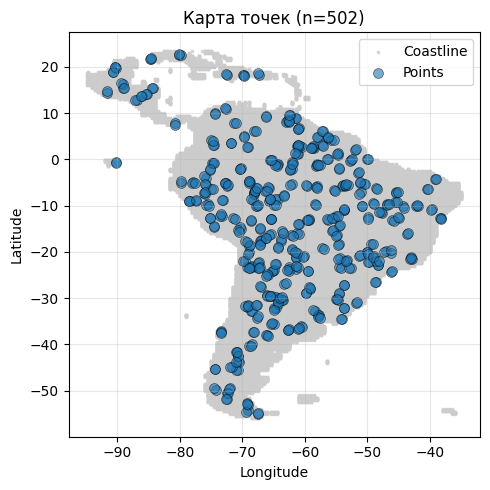

In [8]:
# Получаем coastline из map.json
coastline = map_data.get('coastline', [])

# Пример 1: Train без раскраски
print("Пример 1: Train без раскраски")
plot_map(train, coastline)

## Обучение модели

In [9]:
features_no_coords = [col for col in train.columns if col not in ['ID', 'target']]

# Категориальные признаки
categorical_cols = train[features_no_coords].select_dtypes(include=['object']).columns.tolist()

X_train = train[features_no_coords]
y_train = train['target']
X_test = test[features_no_coords]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Обучаем модель
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=10,
    cat_features=categorical_cols,
    random_seed=42,
    verbose=50
)

print("\nОбучаем модель...")
model.fit(X_train, y_train)

# Предсказания на test
y_pred_test = model.predict_proba(X_test)[:, 1]

Train: (502, 24), Test: (1998, 24)

Обучаем модель...
0:	learn: 0.5710982	total: 17.6ms	remaining: 8.76s
50:	learn: 0.0234889	total: 440ms	remaining: 3.87s
100:	learn: 0.0070158	total: 768ms	remaining: 3.03s
150:	learn: 0.0040941	total: 1.14s	remaining: 2.63s
200:	learn: 0.0030092	total: 1.5s	remaining: 2.23s
250:	learn: 0.0024319	total: 1.85s	remaining: 1.84s
300:	learn: 0.0020560	total: 2.24s	remaining: 1.48s
350:	learn: 0.0017664	total: 2.61s	remaining: 1.11s
400:	learn: 0.0015345	total: 2.98s	remaining: 737ms
450:	learn: 0.0013653	total: 3.37s	remaining: 366ms
499:	learn: 0.0012609	total: 3.73s	remaining: 0us


In [10]:
# Формируем submission
if 'ID' in test.columns:
    submission = test[['ID']].copy()
else:
    submission = pd.DataFrame({'ID': np.arange(len(test))})

submission['target'] = y_pred_test
submission.to_csv('submission.csv', index=False)

print("\n✓ Сабмит сохранен: submission.csv")
print(f"Строк в сабмите: {len(submission)}")
display(submission.head())


✓ Сабмит сохранен: submission.csv
Строк в сабмите: 1998


,ID,target
0,0,0.002409
1,1,0.008593
2,2,0.201212
3,3,0.999322
4,4,0.884064
